In [1]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.applications import EfficientNetB0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# STEP 2: AUTOMATICALLY FIND THE IQ-OTHNCCD DATASET
# ============================================================

import os
from pathlib import Path

# ------------------------------------------------------------
# Kaggle input directory
# ------------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")

# ------------------------------------------------------------
# Class names used by the model
# ------------------------------------------------------------

CLASS_NAMES = [
    "Normal",
    "Benign",
    "Malignant"
]

# ------------------------------------------------------------
# Actual folder names inside the dataset
#
# IMPORTANT:
# The dataset folder is spelled "Bengin cases"
# ------------------------------------------------------------

CLASS_DIRS = {
    "Normal": "Normal cases",
    "Benign": "Bengin cases",
    "Malignant": "Malignant cases"
}

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)


# ============================================================
# SEARCH FOR DATASET
# ============================================================

print("=" * 70)
print("SEARCHING FOR DATASET...")
print("=" * 70)

dataset_root = None


# ------------------------------------------------------------
# Search recursively for "Normal cases"
# ------------------------------------------------------------

for normal_folder in KAGGLE_INPUT.rglob("Normal cases"):

    # Make sure it is actually a directory
    if not normal_folder.is_dir():
        continue

    # The dataset root should be the parent of "Normal cases"
    candidate_root = normal_folder.parent

    normal_path = candidate_root / "Normal cases"
    benign_path = candidate_root / "Bengin cases"
    malignant_path = candidate_root / "Malignant cases"

    # Check that all three required folders exist
    if (
        normal_path.is_dir()
        and benign_path.is_dir()
        and malignant_path.is_dir()
    ):

        dataset_root = candidate_root

        break


# ============================================================
# CHECK RESULT
# ============================================================

if dataset_root is None:

    print("\nERROR: Dataset was NOT found.")
    print("\nKaggle input folders available:")

    for item in KAGGLE_INPUT.iterdir():
        print("   ", item)

    raise FileNotFoundError(
        "\nIQ-OTHNCCD dataset was not found.\n\n"
        "Please go to the Kaggle notebook sidebar -> "
        "Add Input -> search for IQ-OTHNCCD Lung Cancer Dataset "
        "and add it to this notebook."
    )


# Convert Path to string
ROOT = str(dataset_root)


# ============================================================
# VERIFY ALL CLASS FOLDERS
# ============================================================

print("\nDATASET FOUND!")
print("=" * 70)

print("Dataset root:")
print(ROOT)

print("\nClass folders:")

for label, folder in CLASS_DIRS.items():

    folder_path = os.path.join(
        ROOT,
        folder
    )

    exists = os.path.isdir(folder_path)

    print(
        f"{label:10s} : "
        f"{folder_path} "
        f"| exists = {exists}"
    )

    if not exists:
        raise FileNotFoundError(
            f"\nRequired folder is missing:\n{folder_path}"
        )


# ============================================================
# COUNT IMAGES IN EACH CLASS
# ============================================================

print("\nImage counts:")
print("-" * 70)

total_images = 0

for label, folder in CLASS_DIRS.items():

    folder_path = os.path.join(
        ROOT,
        folder
    )

    image_files = [
        file
        for file in os.listdir(folder_path)
        if file.lower().endswith(VALID_EXTENSIONS)
    ]

    count = len(image_files)

    total_images += count

    print(
        f"{label:10s}: {count} images"
    )


print("-" * 70)
print(f"Total images: {total_images}")

print("\nDataset setup completed successfully.")

SEARCHING FOR DATASET...

DATASET FOUND!
Dataset root:
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset

Class folders:
Normal     : /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases | exists = True
Benign     : /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases | exists = True
Malignant  : /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases | exists = True

Image counts:
----------------------------------------------------------------------
Normal    : 416 images
Benign    : 120 images
Malignant : 561 images
----------------------------------------------------------------------
Total images: 1097

Da

In [3]:
# ============================================================
# STEP 3: CREATE CLEAN DATAFRAME
# ============================================================

records = []

for label in CLASS_NAMES:
    folder_path = os.path.join(ROOT, CLASS_DIRS[label])

    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith(VALID_EXTENSIONS):
            records.append({
                "filepath": os.path.join(folder_path, filename),
                "label": label
            })

df = pd.DataFrame(records)

# Remove duplicate paths
df = df.drop_duplicates(subset="filepath").reset_index(drop=True)

if df.empty:
    raise ValueError("No images were found. Check ROOT and CLASS_DIRS.")

print("Total original images:", len(df))
print("\nOriginal class distribution:")
print(df["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))

display(df.head())

Total original images: 1097

Original class distribution:
label
Normal       416
Benign       120
Malignant    561
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal
1,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal
2,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal
3,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal
4,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal


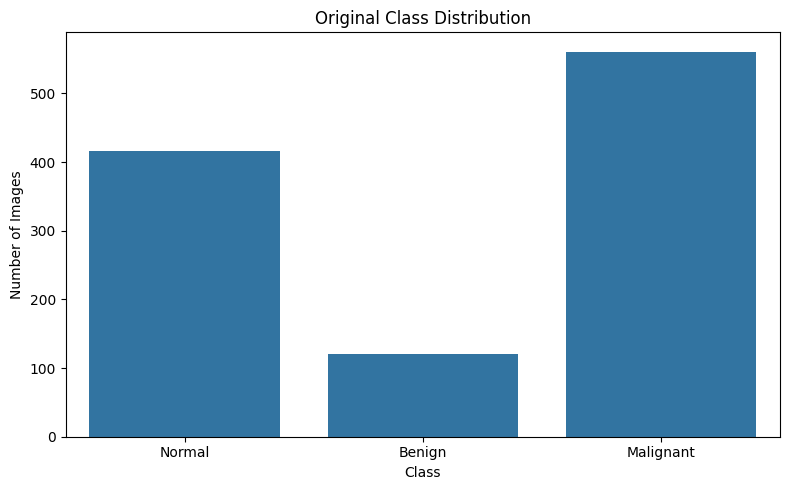

In [4]:
# ============================================================
# STEP 4: ORIGINAL CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="label", order=CLASS_NAMES)
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# STEP 5: STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# 70% TRAIN | 15% VALIDATION | 15% TEST
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, split_df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:
    counts = split_df["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
    print(f"\n{name}: {len(split_df)} images")
    print(counts)


TRAIN: 767 images
label
Normal       291
Benign        84
Malignant    392
Name: count, dtype: int64

VALIDATION: 165 images
label
Normal       63
Benign       18
Malignant    84
Name: count, dtype: int64

TEST: 165 images
label
Normal       62
Benign       18
Malignant    85
Name: count, dtype: int64


In [6]:
# ============================================================
# STEP 6: CHECK FOR FILEPATH LEAKAGE
# ============================================================

train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test:", len(train_paths & test_paths))
print("Validation ∩ Test:", len(val_paths & test_paths))

assert len(train_paths & val_paths) == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths & test_paths) == 0

print("\nSUCCESS: No filepath overlap between splits.")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

SUCCESS: No filepath overlap between splits.


In [7]:
# ============================================================
# STEP 7: CREATE BALANCED TRAINING DATASET
# ============================================================
# IMPORTANT:
# Only TRAIN images are copied/augmented.
# Validation and TEST images are never augmented or copied here.

IMG_SIZE = (224, 224)
BALANCED_ROOT = "/kaggle/working/balanced_augmented_train"

if os.path.exists(BALANCED_ROOT):
    shutil.rmtree(BALANCED_ROOT)

for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(BALANCED_ROOT, class_name), exist_ok=True)

train_counts = (
    train_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

if (train_counts == 0).any():
    raise ValueError("At least one class has zero training images.")

# Balance to the size of the largest original training class.
TARGET_PER_CLASS = int(train_counts.max())

print("Original training counts:")
print(train_counts)
print("\nTarget images per class:", TARGET_PER_CLASS)

# Conservative augmentation for medical images.
# No vertical flip; no extreme transformations.
augmentation_generator = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    shear_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest"
)

for class_name in CLASS_NAMES:

    class_df = (
        train_df[train_df["label"] == class_name]
        .reset_index(drop=True)
    )

    output_class_dir = os.path.join(BALANCED_ROOT, class_name)

    # Copy original training images
    for idx, row in class_df.iterrows():

        source_path = row["filepath"]

        if not os.path.isfile(source_path):
            raise FileNotFoundError(f"Training image not found: {source_path}")

        extension = Path(source_path).suffix.lower()

        destination_path = os.path.join(
            output_class_dir,
            f"original_{idx:06d}{extension}"
        )

        shutil.copy2(source_path, destination_path)

    current_count = len(class_df)
    aug_index = 0

    # Generate only enough augmented images to balance the class
    while current_count < TARGET_PER_CLASS:

        row = class_df.iloc[aug_index % len(class_df)]
        source_path = row["filepath"]

        image = tf.keras.utils.load_img(
            source_path,
            target_size=IMG_SIZE
        )

        image_array = tf.keras.utils.img_to_array(image)
        image_array = np.expand_dims(image_array, axis=0)

        batch = next(
            augmentation_generator.flow(
                image_array,
                batch_size=1,
                shuffle=False,
                seed=SEED + aug_index
            )
        )

        augmented_image = tf.keras.utils.array_to_img(batch[0])

        output_path = os.path.join(
            output_class_dir,
            f"augmented_{aug_index:06d}.jpg"
        )

        augmented_image.save(output_path, quality=95)

        current_count += 1
        aug_index += 1

    print(f"{class_name:10s}: {current_count} images created")

print("\nSUCCESS: Balanced training dataset created.")

Original training counts:
label
Normal       291
Benign        84
Malignant    392
Name: count, dtype: int64

Target images per class: 392
Normal    : 392 images created
Benign    : 392 images created
Malignant : 392 images created

SUCCESS: Balanced training dataset created.


In [8]:
# ============================================================
# STEP 8: BUILD DATAFRAME FOR BALANCED TRAINING SET
# ============================================================

balanced_records = []

for class_name in CLASS_NAMES:

    class_dir = os.path.join(BALANCED_ROOT, class_name)

    for filename in sorted(os.listdir(class_dir)):

        if filename.lower().endswith(VALID_EXTENSIONS):

            balanced_records.append({
                "filepath": os.path.join(class_dir, filename),
                "label": class_name
            })

balanced_train_df = pd.DataFrame(balanced_records)

balanced_counts = (
    balanced_train_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

print("Balanced training dataset size:", len(balanced_train_df))
print("\nBalanced training class distribution:")
print(balanced_counts)

assert balanced_counts.min() > 0
assert balanced_counts.nunique() == 1

print("\nSUCCESS: All classes are exactly balanced.")

Balanced training dataset size: 1176

Balanced training class distribution:
label
Normal       392
Benign       392
Malignant    392
Name: count, dtype: int64

SUCCESS: All classes are exactly balanced.


,Original Training,Balanced Training
label,,
Normal,291,392
Benign,84,392
Malignant,392,392


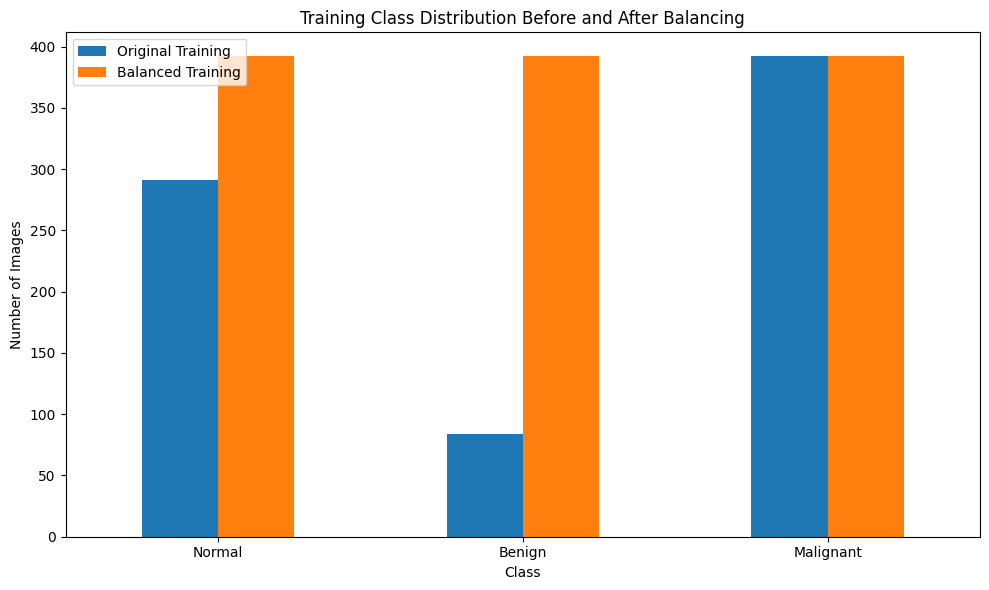

In [9]:
# ============================================================
# STEP 9: BEFORE VS AFTER BALANCING
# ============================================================

comparison_df = pd.DataFrame({
    "Original Training": train_df["label"].value_counts().reindex(CLASS_NAMES),
    "Balanced Training": balanced_train_df["label"].value_counts().reindex(CLASS_NAMES)
}).fillna(0).astype(int)

display(comparison_df)

comparison_df.plot(kind="bar", figsize=(10, 6))
plt.title("Training Class Distribution Before and After Balancing")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# STEP 10: IMAGE PARAMETERS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 32
Number of classes: 3


In [11]:
# ============================================================
# STEP 11: DATA GENERATORS
# ============================================================
# The saved training set has already been balanced/augmented.
# Therefore we do NOT augment it again here.
#
# Validation and test are never augmented.
#
# Keras EfficientNetB0 includes its expected input rescaling,
# so rescale=1/255 is intentionally not added here.

train_datagen = ImageDataGenerator()
val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=balanced_train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

assert train_generator.class_indices == {
    "Normal": 0,
    "Benign": 1,
    "Malignant": 2
}

Found 1176 validated image filenames belonging to 3 classes.
Found 165 validated image filenames belonging to 3 classes.
Found 165 validated image filenames belonging to 3 classes.

Class indices:
{'Normal': 0, 'Benign': 1, 'Malignant': 2}


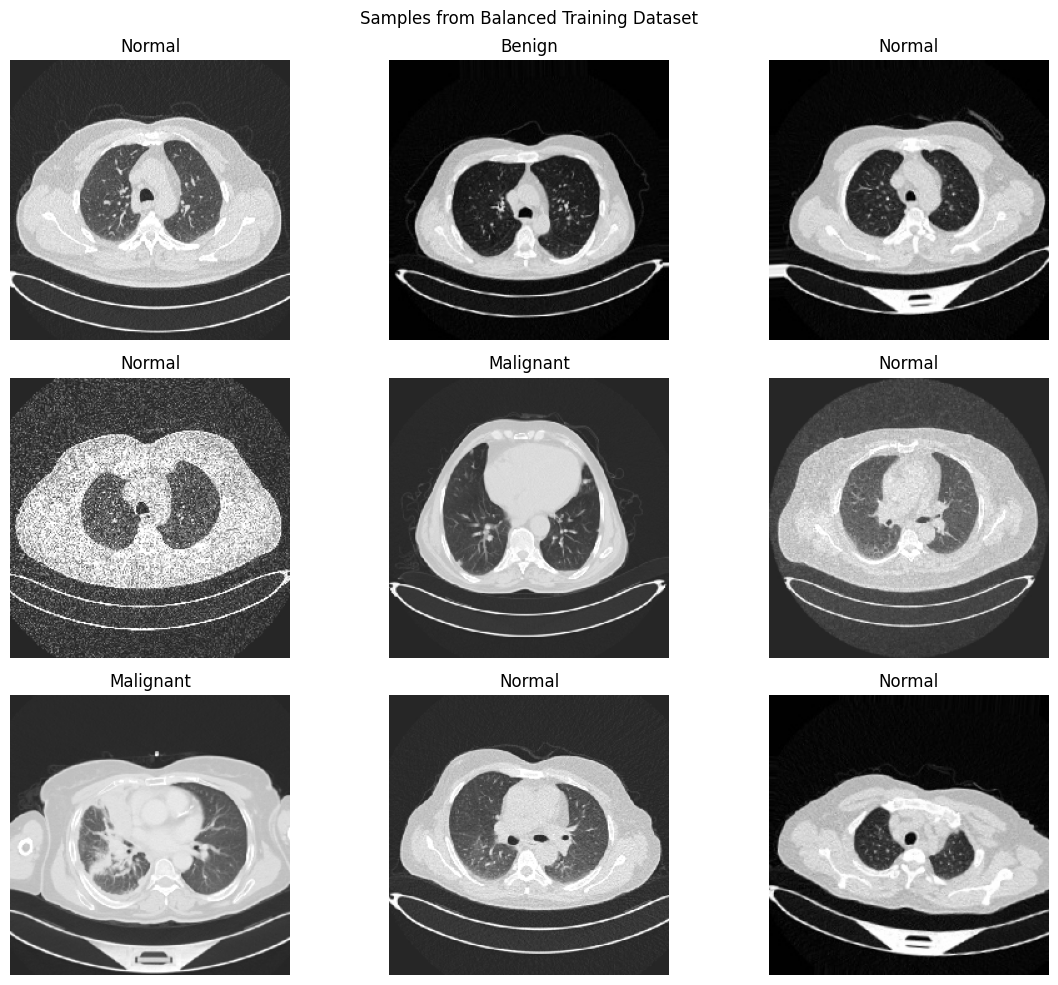

In [12]:
# ============================================================
# STEP 12: VISUALIZE TRAINING IMAGES
# ============================================================

images, labels = next(train_generator)

plt.figure(figsize=(12, 10))

for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype("uint8"))
    label_index = np.argmax(labels[i])
    plt.title(CLASS_NAMES[label_index])
    plt.axis("off")

plt.suptitle("Samples from Balanced Training Dataset")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# STEP 13: BUILD EFFICIENTNETB0
# ============================================================

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Stage 1: freeze pretrained feature extractor
base_model.trainable = False

inputs = layers.Input(
    shape=(*IMG_SIZE, 3),
    name="input_image"
)

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.BatchNormalization(name="classifier_bn")(x)
x = layers.Dropout(0.35, name="dropout_1")(x)
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="dense_256"
)(x)
x = layers.Dropout(0.30, name="dropout_2")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_LungCancer"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

model.summary()

I0000 00:00:1787289635.935619      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_LungCancer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_bn                   │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,398 (16.72 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [14]:
# ============================================================
# STEP 14: CALLBACKS
# ============================================================

MODEL_PATH = "/kaggle/working/best_efficientnetb0.keras"

callbacks = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


In [15]:
# ============================================================
# STEP 15: TRAIN CLASSIFICATION HEAD
# ============================================================

history_head = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1787289668.879426     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.5704 - loss: 1.2020 - top2_accuracy: 0.8475
Epoch 1: val_accuracy improved from None to 0.84242, saving model to /kaggle/working/best_efficientnetb0.keras

Epoch 1: finished saving model to /kaggle/working/best_efficientnetb0.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6956 - loss: 0.9444 - top2_accuracy: 0.9175 - val_accuracy: 0.8424 - val_loss: 0.5866 - val_top2_accuracy: 0.9879 - learning_rate: 3.0000e-04
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8095 - loss: 0.6267 - top2_accuracy: 0.9833
Epoch 2: val_accuracy improved from 0.84242 to 0.89697, saving model to /kaggle/working/best_efficientnetb0.keras

Epoch 2: finished saving model to /kaggle/working/best_efficientnetb0.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.8172 - loss: 0.6139 - top2_accuracy: 0.9821 - val_accuracy: 0.8970 - val_loss: 0.5156 - val_top2_accuracy: 1.0000 - learning_rate: 3.0000e-04
Epoch 3/20
37/37 ━━━

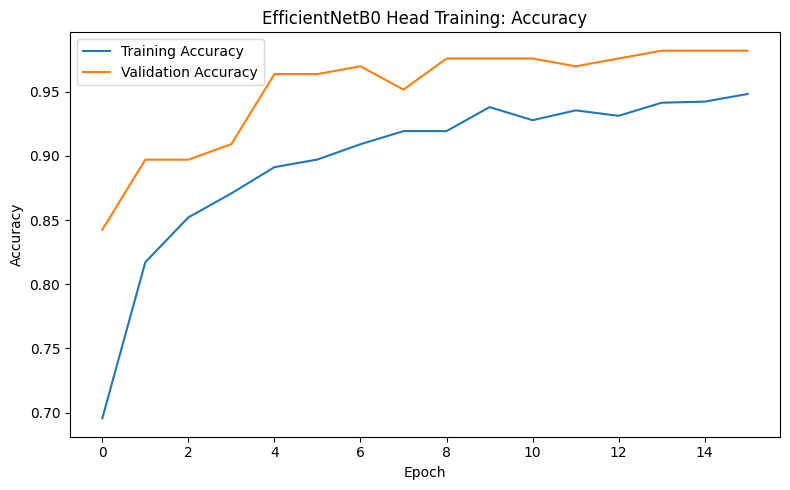

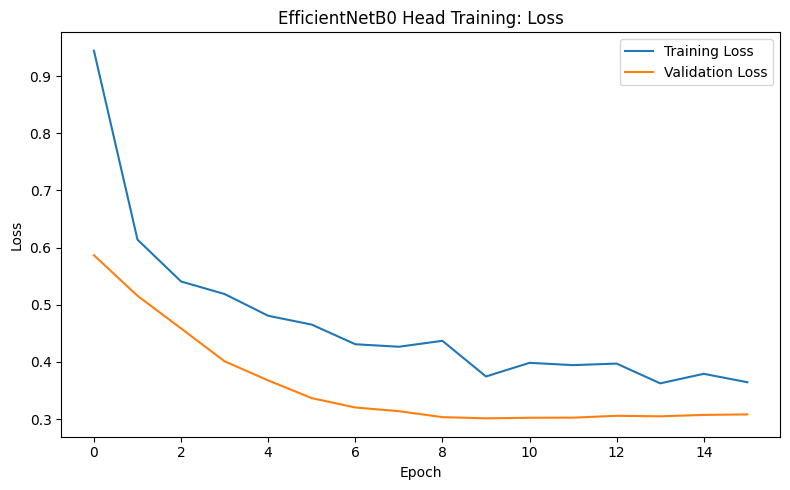

In [16]:
# ============================================================
# STEP 16: TRAINING CURVES
# ============================================================

def plot_history(history, title_prefix):
    history_dict = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["accuracy"], label="Training Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="Training Loss")
    plt.plot(history_dict["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_head, "EfficientNetB0 Head Training")

In [17]:
# ============================================================
# STEP 17: FINE-TUNE LAST PART OF EFFICIENTNETB0
# ============================================================

# Load the best checkpoint from Stage 1
model = tf.keras.models.load_model(MODEL_PATH)

# Find the nested EfficientNet model by its name
base_model = model.get_layer("efficientnetb0")

base_model.trainable = True

# Freeze all but the last 40 layers.
fine_tune_from = max(0, len(base_model.layers) - 40)

for i, layer in enumerate(base_model.layers):

    if i < fine_tune_from:
        layer.trainable = False

    elif isinstance(layer, layers.BatchNormalization):
        # Keep BatchNorm frozen during fine-tuning for stability.
        layer.trainable = False

    else:
        layer.trainable = True

trainable_count = sum(
    int(layer.trainable)
    for layer in base_model.layers
)

print("Total EfficientNet layers:", len(base_model.layers))
print("Trainable EfficientNet layers:", trainable_count)

Total EfficientNet layers: 238
Trainable EfficientNet layers: 32


In [18]:
# ============================================================
# STEP 18: RECOMPILE FOR FINE-TUNING
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

model.summary()

Model: "EfficientNetB0_LungCancer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_bn                   │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,398 (16.72 MB)

 Trainable params: 2,368,787 (9.04 MB)

 Non-trainable params: 2,014,611 (7.69 MB)

Epoch 1/25


2026-08-21 05:23:21.555553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-21 05:23:21.761581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-21 05:23:22.037255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-21 05:23:22.243294: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


29/37 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9436 - loss: 0.2976 - top2_accuracy: 0.9992

2026-08-21 05:23:41.032813: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-21 05:23:41.241356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-21 05:23:41.520864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-21 05:23:41.729270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.9444 - loss: 0.2971 - top2_accuracy: 0.9987
Epoch 1: val_accuracy improved from None to 0.98182, saving model to /kaggle/working/best_efficientnetb0.keras

Epoch 1: finished saving model to /kaggle/working/best_efficientnetb0.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 966ms/step - accuracy: 0.9473 - loss: 0.2962 - top2_accuracy: 0.9966 - val_accuracy: 0.9818 - val_loss: 0.2413 - val_top2_accuracy: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9475 - loss: 0.3060 - top2_accuracy: 0.9985
Epoch 2: val_accuracy did not improve from 0.98182
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9490 - loss: 0.3006 - top2_accuracy: 0.9974 - val_accuracy: 0.9818 - val_loss: 0.2386 - val_top2_accuracy: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9546 - loss: 0.2769 - top2_accuracy: 1.0000
Epoch 3: val_accuracy did not improve from 0.9818

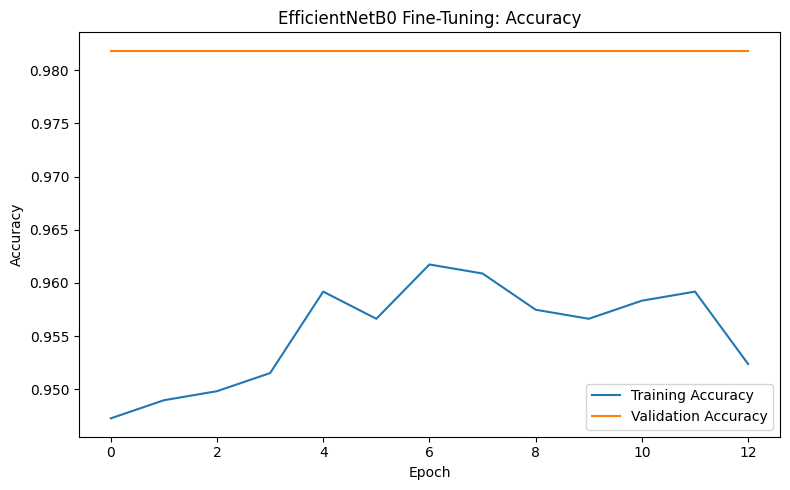

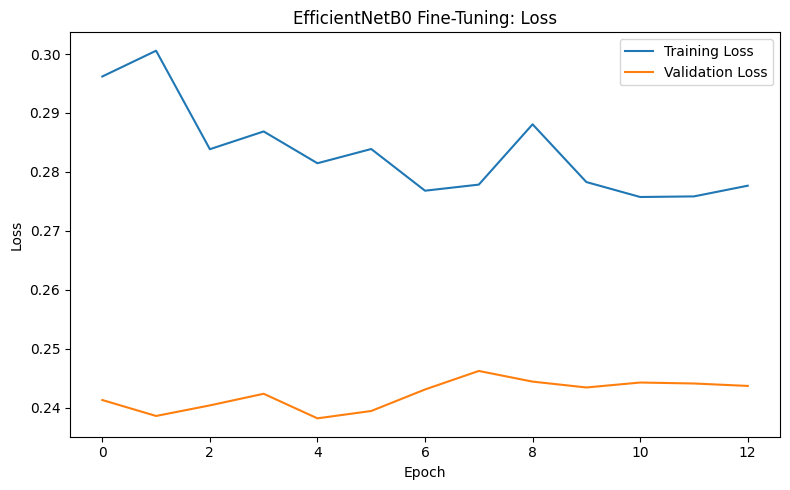

In [19]:
# ============================================================
# STEP 19: FINE-TUNE
# ============================================================

fine_tune_callbacks = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=fine_tune_callbacks,
    verbose=1
)

plot_history(history_finetune, "EfficientNetB0 Fine-Tuning")

In [20]:
# ============================================================
# STEP 20: LOAD BEST MODEL
# ============================================================

best_model = tf.keras.models.load_model(MODEL_PATH)

print("Best EfficientNetB0 model loaded successfully.")

Best EfficientNetB0 model loaded successfully.


In [21]:
# ============================================================
# STEP 21: FINAL TEST EVALUATION
# ============================================================

test_generator.reset()

test_results = best_model.evaluate(
    test_generator,
    verbose=1,
    return_dict=True
)

print("\n======================================")
print("FINAL EFFICIENTNETB0 TEST RESULTS")
print("======================================")

for metric_name, value in test_results.items():
    print(f"{metric_name:15s}: {value:.4f}")

print(f"Test Accuracy (%): {test_results['accuracy'] * 100:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9576 - loss: 0.2669 - top2_accuracy: 1.0000 

FINAL EFFICIENTNETB0 TEST RESULTS
accuracy       : 0.9576
loss           : 0.2669
top2_accuracy  : 1.0000
Test Accuracy (%): 95.76


In [22]:
# ============================================================
# STEP 22: TEST PREDICTIONS
# ============================================================

test_generator.reset()

y_prob = best_model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

print("True labels:", len(y_true))
print("Predictions:", len(y_pred))

assert len(y_true) == len(y_pred)
assert y_prob.shape[0] == len(y_true)

6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step 
True labels: 165
Predictions: 165


In [23]:
# ============================================================
# STEP 23: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal     0.9365    0.9516    0.9440        62
      Benign     0.8235    0.7778    0.8000        18
   Malignant     1.0000    1.0000    1.0000        85

    accuracy                         0.9576       165
   macro avg     0.9200    0.9098    0.9147       165
weighted avg     0.9569    0.9576    0.9571       165



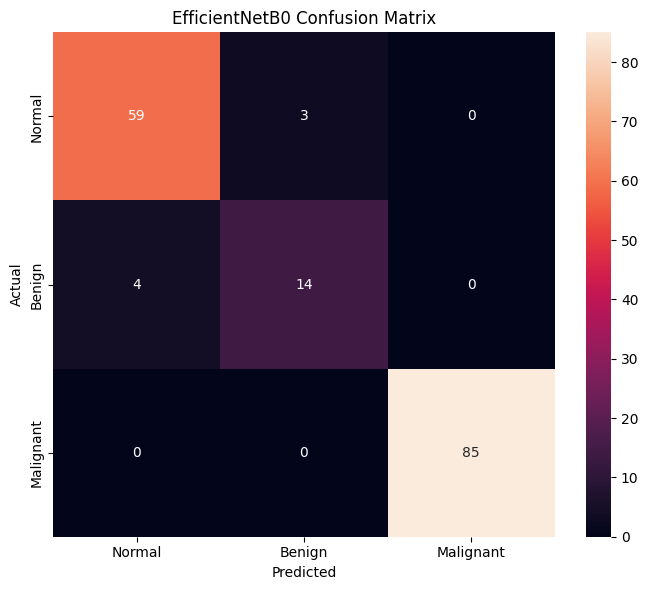

In [24]:
# ============================================================
# STEP 24: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# STEP 25: FINAL METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.957576
1,Macro Precision,0.920012
2,Macro Recall,0.909797
3,Macro F1,0.914667


In [26]:
# ============================================================
# STEP 26: MULTICLASS ROC-AUC
# ============================================================

y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=NUM_CLASSES
)

macro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="macro"
)

per_class_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average=None
)

print("Macro ROC-AUC:", round(macro_auc, 4))

auc_table = pd.DataFrame({
    "Class": CLASS_NAMES,
    "ROC-AUC": per_class_auc
})

display(auc_table)

Macro ROC-AUC: 0.9892


,Class,ROC-AUC
0,Normal,0.990918
1,Benign,0.976568
2,Malignant,1.000000


In [27]:
# ============================================================
# STEP 27: ERROR ANALYSIS
# ============================================================

error_df = test_df.copy().reset_index(drop=True)

error_df["True"] = [
    CLASS_NAMES[i] for i in y_true
]

error_df["Predicted"] = [
    CLASS_NAMES[i] for i in y_pred
]

error_df["Confidence"] = np.max(y_prob, axis=1)

errors = (
    error_df[error_df["True"] != error_df["Predicted"]]
    .sort_values("Confidence", ascending=False)
    .reset_index(drop=True)
)

print("Number of incorrect predictions:", len(errors))

display(errors.head(20))

Number of incorrect predictions: 7


,filepath,label,True,Predicted,Confidence
0,/kaggle/input/datasets/adityamahimkar/iqothncc...,Benign,Benign,Normal,0.985072
1,/kaggle/input/datasets/adityamahimkar/iqothncc...,Benign,Benign,Normal,0.876741
2,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal,Normal,Benign,0.563917
3,/kaggle/input/datasets/adityamahimkar/iqothncc...,Benign,Benign,Normal,0.556188
4,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal,Normal,Benign,0.546669
5,/kaggle/input/datasets/adityamahimkar/iqothncc...,Normal,Normal,Benign,0.540870
6,/kaggle/input/datasets/adityamahimkar/iqothncc...,Benign,Benign,Normal,0.539881


In [28]:
# ============================================================
# STEP 28: SAVE FINAL MODEL AND METRICS
# ============================================================

FINAL_MODEL_PATH = "/kaggle/working/final_lung_cancer_efficientnetb0.keras"
METRICS_PATH = "/kaggle/working/final_metrics.csv"

best_model.save(FINAL_MODEL_PATH)
results.to_csv(METRICS_PATH, index=False)

print("Final model:", FINAL_MODEL_PATH)
print("Metrics CSV:", METRICS_PATH)

Final model: /kaggle/working/final_lung_cancer_efficientnetb0.keras
Metrics CSV: /kaggle/working/final_metrics.csv
